In [1]:
# Data collection command:
# `python comet_download.py --project=ns-autostep-feature-search-results --n_threads=8`

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

## Load Data

In [2]:
save_path = 'figures/'
config_data_path = 'data/ns-autostep-feature-search-results_params.csv'
run_data_path = 'data/ns-autostep-feature-search-results_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
{k: len(v) for k, v in config_dfs.items()}

{'median_utility_reset': 30,
 'zero_utility_reset': 30,
 'perfect_features_baseline': 29,
 'static_features_with_perfect_features': 30,
 'fs_with_frozen_perfect_features': 30,
 'adaptive_lr_frozen_perfect_features': 30,
 'median_utility_reset_v2': 30,
 'adaptive_init_lr': 30}

## Comparison

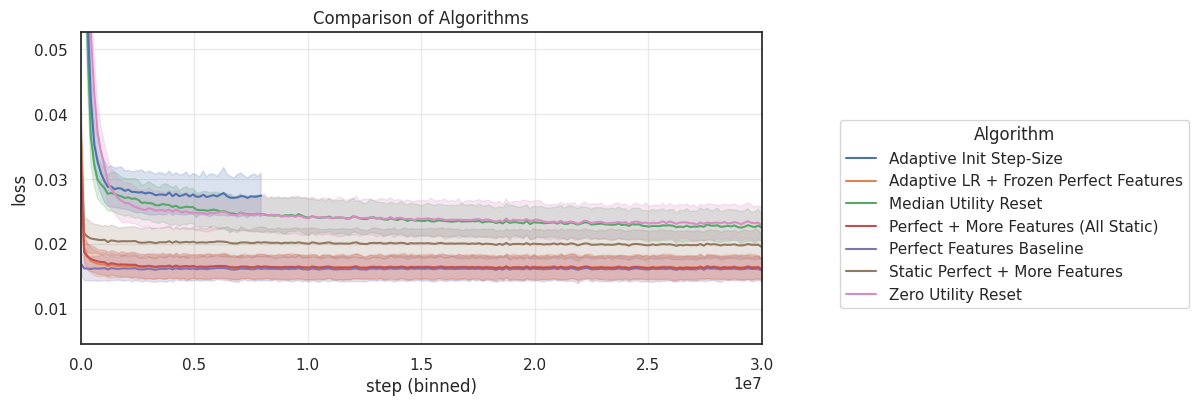

In [8]:
full_combined_run_df = pd.concat(list(run_dfs.values()))
full_combined_config_df = pd.concat(list(config_dfs.values()))

algo_map = {
    'median_utility_reset': 'Median Utility Reset',
    'zero_utility_reset': 'Zero Utility Reset',
    'perfect_features_baseline': 'Perfect Features Baseline',
    'static_features_with_perfect_features': 'Perfect + More Features (All Static)',
    'fs_with_frozen_perfect_features': 'Static Perfect + More Features',
    'adaptive_lr_frozen_perfect_features': 'Adaptive LR + Frozen Perfect Features',
    'adaptive_init_lr': 'Adaptive Init Step-Size',
}
full_combined_config_df = full_combined_config_df[full_combined_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = full_combined_config_df['run_id'].unique()
full_combined_run_df = full_combined_run_df[full_combined_run_df['run_id'].isin(valid_run_ids)].copy()
full_combined_config_df['algo'] = full_combined_config_df['sweep_name'].map(algo_map)


plot_learning_curves(
    run_df = full_combined_run_df,
    config_df = full_combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms')
plt.show()

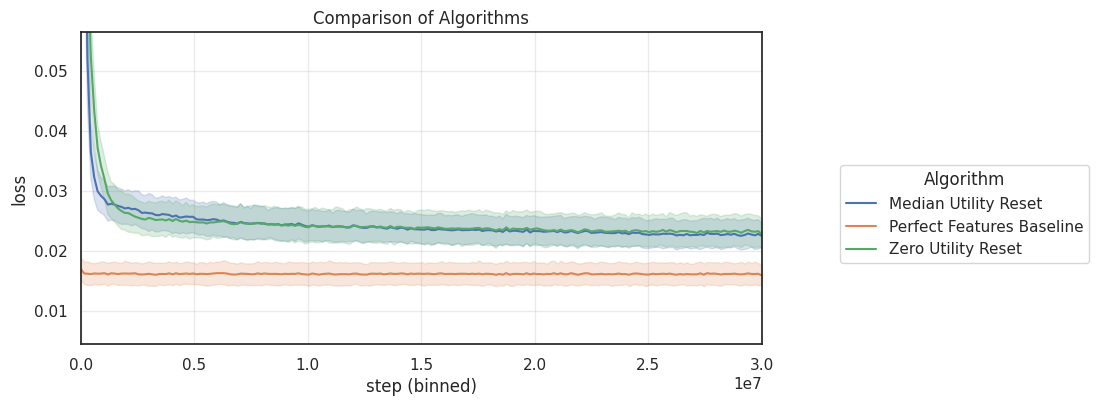

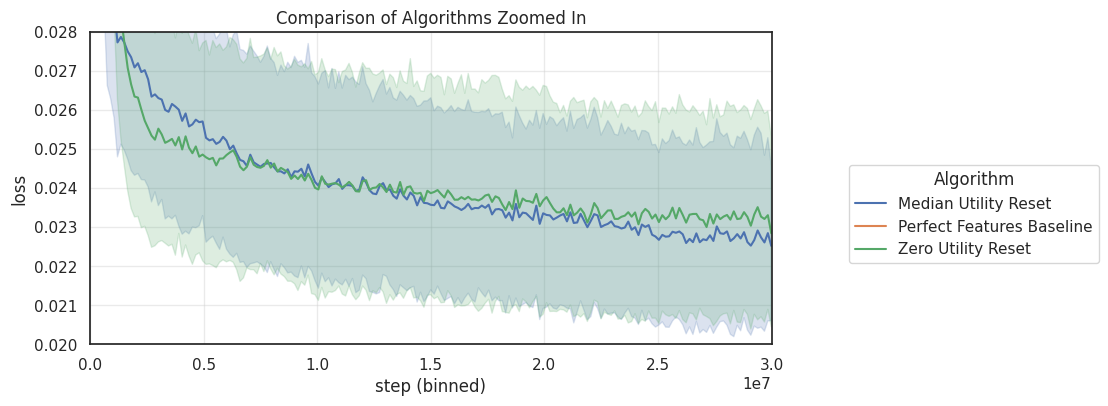

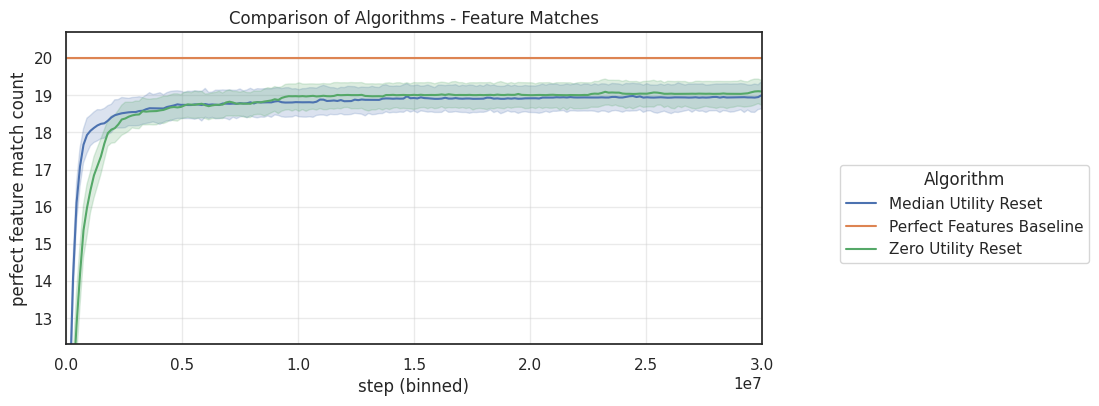

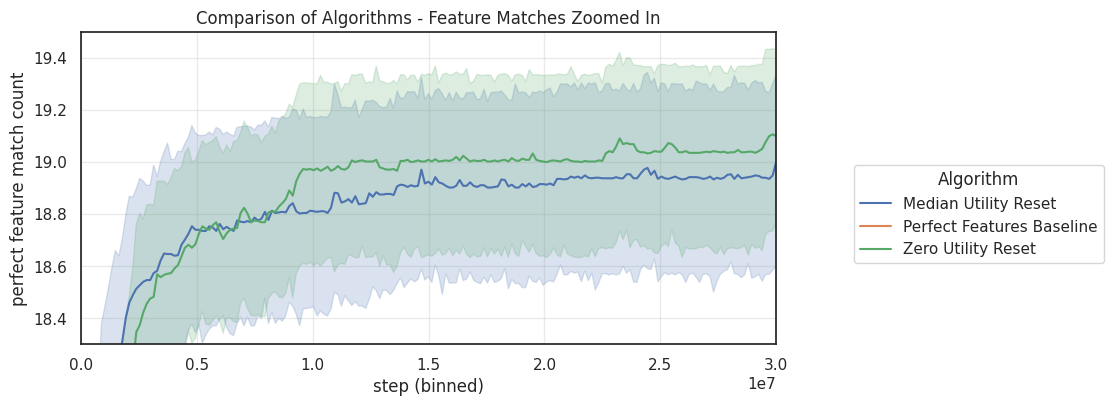

In [6]:
combined_run_df = pd.concat(list(run_dfs.values()))
combined_config_df = pd.concat(list(config_dfs.values()))

algo_map = {
    'median_utility_reset': 'Median Utility Reset',
    'zero_utility_reset': 'Zero Utility Reset',
    'perfect_features_baseline': 'Perfect Features Baseline',
}
combined_config_df = combined_config_df[combined_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms')
plt.show()


plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms Zoomed In')
plt.ylim(0.02, 0.028)
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms - Feature Matches')
plt.show()


plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms - Feature Matches Zoomed In')
plt.ylim(18.3, 19.5)
plt.show()

## How many runs find the perfect features?

Text(0.5, 1.0, 'Fraction of Runs with Perfect Features')

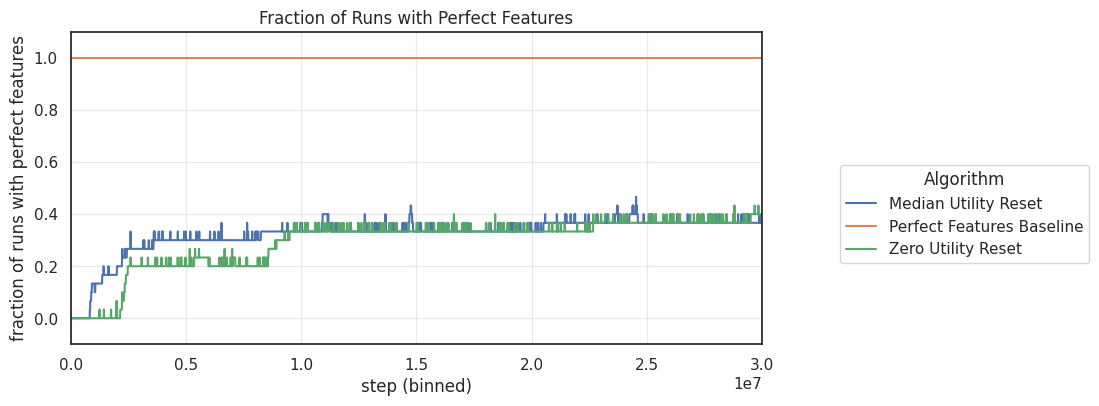

In [7]:
combined_run_df['are_features_perfect'] = combined_run_df['feature_match/perfect_match_count'].apply(lambda x: int(x == 20))
combined_df = combined_run_df.merge(combined_config_df, on='run_id', how='left')
perfect_features_df = combined_df.groupby(['step', 'algo'])['are_features_perfect'].mean().reset_index()
perfect_features_df['run_id'] = perfect_features_df['algo']

plot_learning_curves(
    run_df = perfect_features_df,
    n_bins = 10000,
    figsize = (8, 4),
    y_col = 'are_features_perfect',
    y_label = 'fraction of runs with perfect features',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = False,
)
plt.title('Fraction of Runs with Perfect Features')

## What if matches don't need to be perfect?

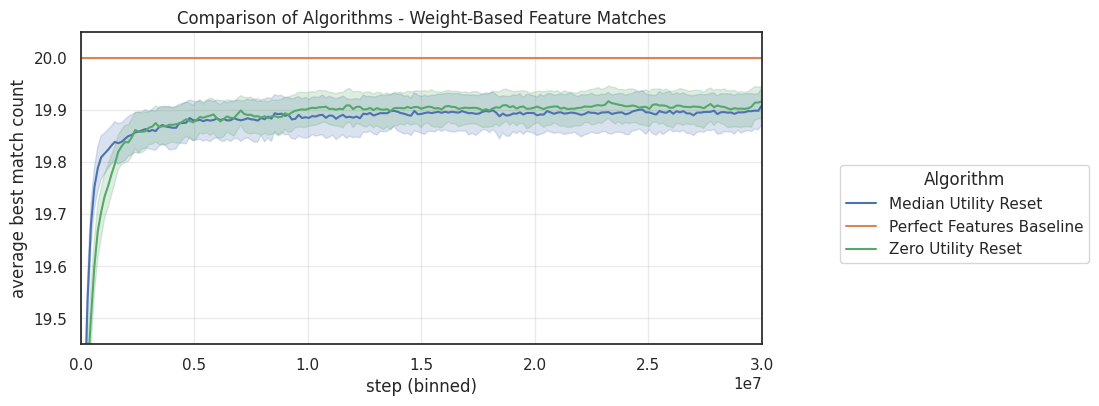

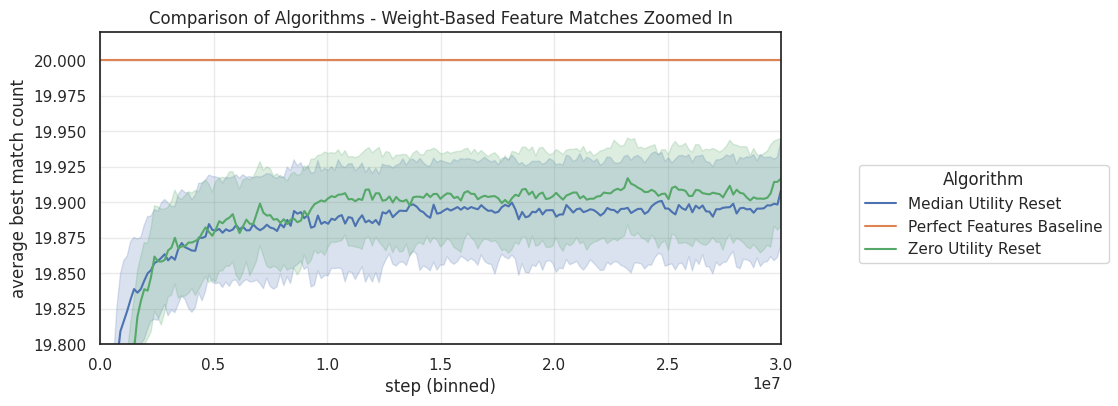

In [8]:
plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/average_best_match_count',
    y_label = 'average best match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms - Weight-Based Feature Matches')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/average_best_match_count',
    y_label = 'average best match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms - Weight-Based Feature Matches Zoomed In')
plt.ylim(19.8, 20.02)
plt.show()


## What are the distances between the features with and without weighting?

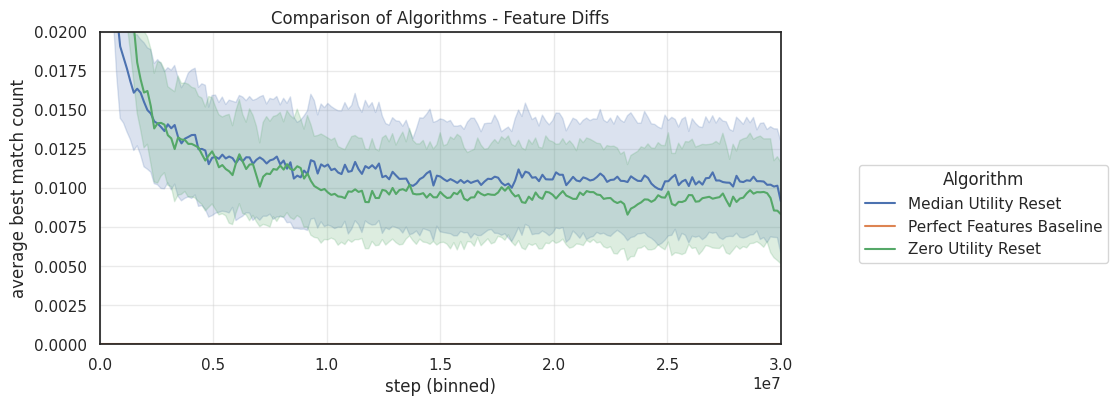

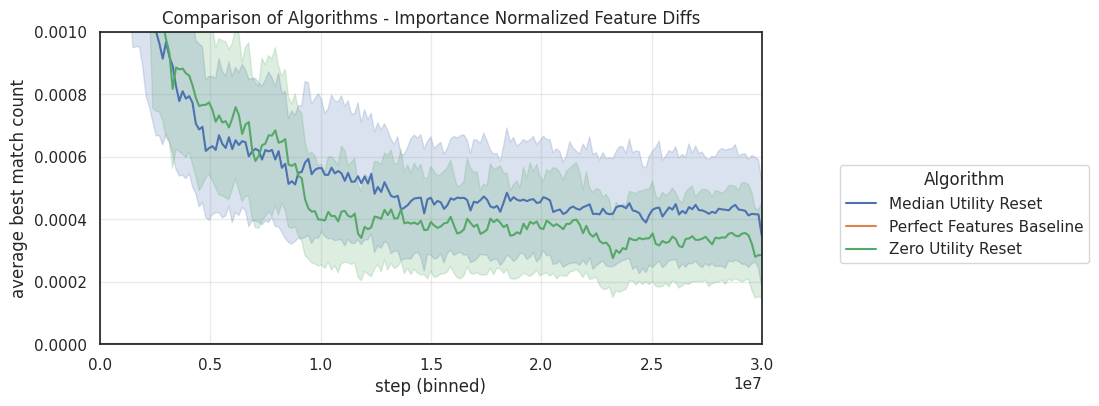

In [9]:
plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/average_best_match_normalized_distance',
    y_label = 'average best match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms - Feature Diffs')
plt.ylim(0.0, 0.02)
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/best_match_output_weighted_normalized_distance',
    y_label = 'average best match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
plt.title('Comparison of Algorithms - Importance Normalized Feature Diffs')
plt.ylim(0.0, 0.001)
plt.show()

## Step-size Analysis

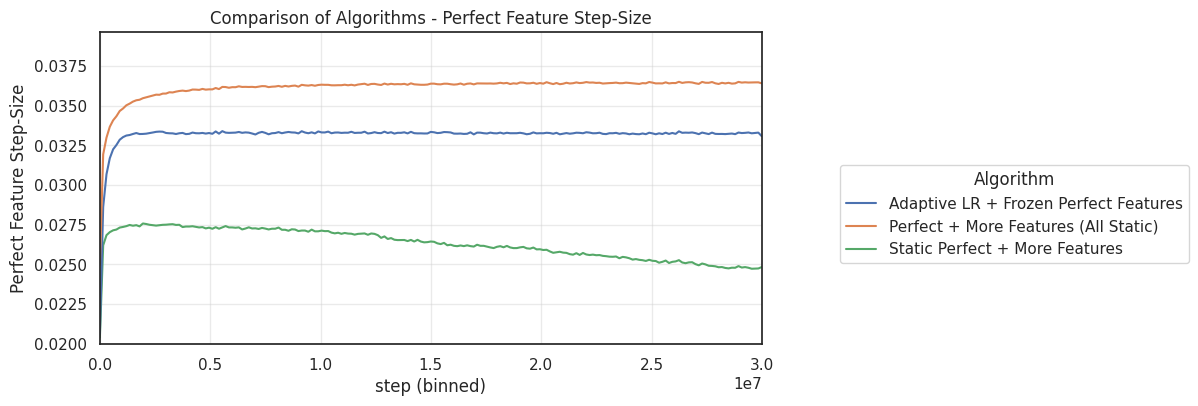

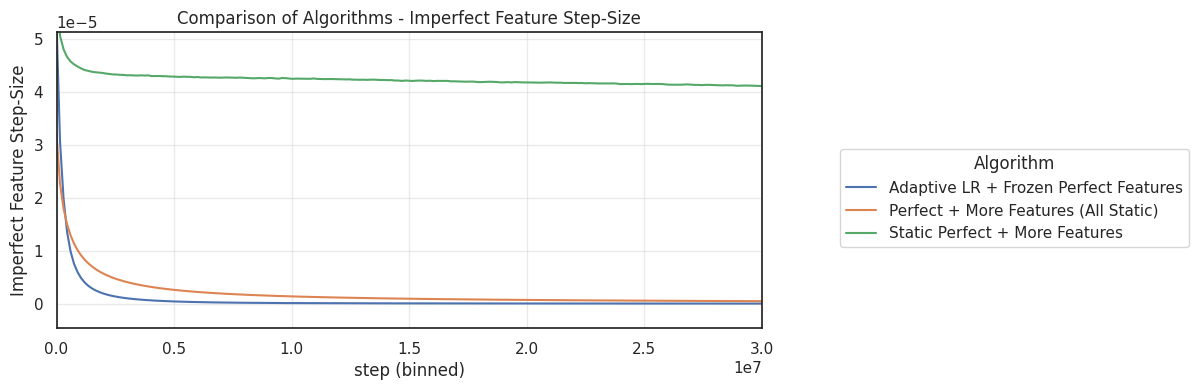

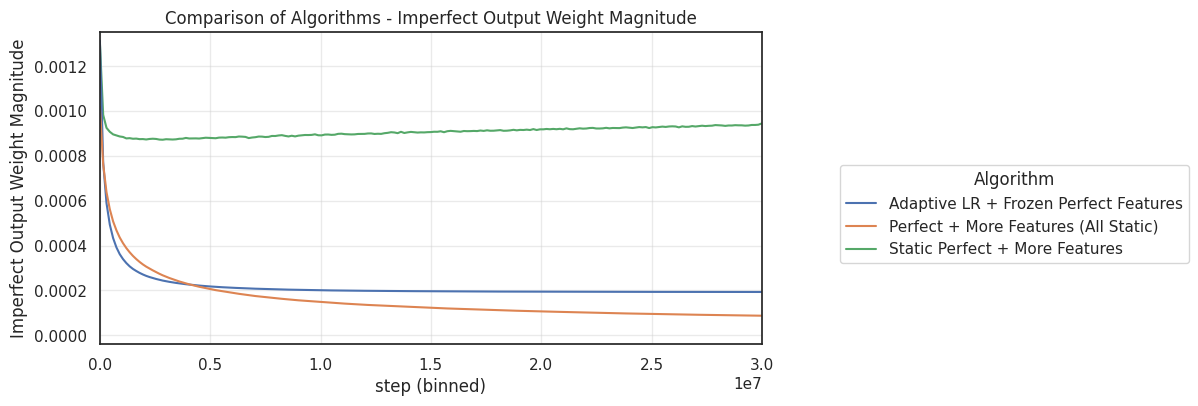

In [15]:
plot_config_df = full_combined_config_df[full_combined_config_df['sweep_name'].isin(
    ['static_features_with_perfect_features', 'fs_with_frozen_perfect_features', 'adaptive_lr_frozen_perfect_features'])]
valid_run_ids = plot_config_df['run_id'].unique()
plot_run_df = full_combined_run_df[full_combined_run_df['run_id'].isin(valid_run_ids)]

plot_learning_curves(
    run_df = plot_run_df,
    config_df = plot_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'optimizer/perfect_mean_step_size',
    y_label = 'Perfect Feature Step-Size',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = False,
)
plt.title('Comparison of Algorithms - Perfect Feature Step-Size')
plt.show()

plot_learning_curves(
    run_df = plot_run_df,
    config_df = plot_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'optimizer/imperfect_mean_step_size',
    y_label = 'Imperfect Feature Step-Size',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = False,
)
plt.title('Comparison of Algorithms - Imperfect Feature Step-Size')
# plt.yscale('log')
plt.show()

plot_learning_curves(
    run_df = plot_run_df,
    config_df = plot_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'model/imperfect_output_weight_l1',
    y_label = 'Imperfect Output Weight Magnitude',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = False,
)
plt.title('Comparison of Algorithms - Imperfect Output Weight Magnitude')
plt.show()

### Potential Relationship Between Feature Matching and Baseline Loss

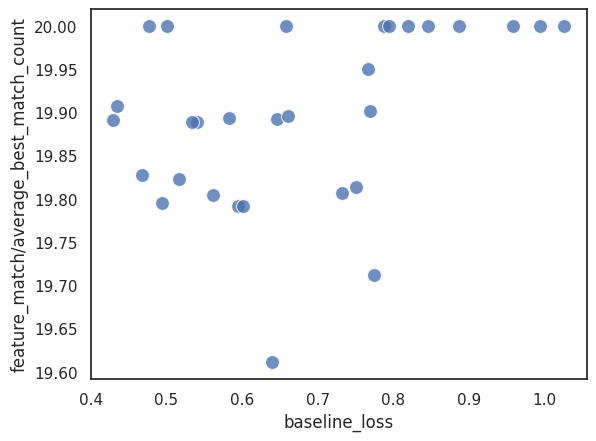

R^2 (baseline_loss vs. average_best_match_count): 0.1522


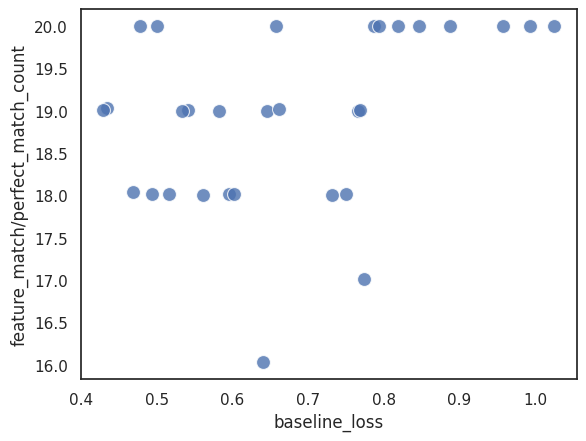

R^2 (baseline_loss vs. perfect_match_count): 0.1369


In [25]:
plot_config_df = config_dfs['median_utility_reset']
plot_run_df = run_dfs['median_utility_reset']

step_threshold = plot_run_df['step'].max() * 0.95
last_5_percent_steps = plot_run_df[plot_run_df['step'] >= step_threshold]
plot_df = last_5_percent_steps.groupby('run_id')[[
    'feature_match/average_best_match_count', 'feature_match/perfect_match_count', 'baseline_loss'
]].mean()

# Scatter and r^2 for average_best_match_count
sns.scatterplot(data=plot_df, x='baseline_loss', y='feature_match/average_best_match_count', alpha=0.8, s=100)
plt.show()
r2_avg_best = r2_score(
    plot_df['feature_match/average_best_match_count'],
    pd.Series(np.poly1d(np.polyfit(plot_df['baseline_loss'], plot_df['feature_match/average_best_match_count'], 1))(plot_df['baseline_loss']))
)
print(f"R^2 (baseline_loss vs. average_best_match_count): {r2_avg_best:.4f}")

# Scatter and r^2 for perfect_match_count
sns.scatterplot(data=plot_df, x='baseline_loss', y='feature_match/perfect_match_count', alpha=0.8, s=100)
plt.show()
r2_perfect = r2_score(
    plot_df['feature_match/perfect_match_count'],
    pd.Series(np.poly1d(np.polyfit(plot_df['baseline_loss'], plot_df['feature_match/perfect_match_count'], 1))(plot_df['baseline_loss']))
)
print(f"R^2 (baseline_loss vs. perfect_match_count): {r2_perfect:.4f}")


## Effect of Ataptive Initial Step-Size

In [11]:
plot_run_df = pd.concat(list(run_dfs.values()))
plot_config_df = pd.concat(list(config_dfs.values()))

algo_map = {
    'median_utility_reset_v2': 'Constant Initial Step-Size',
    'perfect_features_baseline': 'Perfect Features Baseline',
    'adaptive_init_lr': 'Adaptive Init Step-Size',
}
plot_config_df = plot_config_df[plot_config_df['sweep_name'].isin(algo_map.keys())].copy()
valid_run_ids = plot_config_df['run_id'].unique()
plot_run_df = plot_run_df[plot_run_df['run_id'].isin(valid_run_ids)].copy()
plot_config_df['algo'] = plot_config_df['sweep_name'].map(algo_map)
plot_run_df = plot_run_df[plot_run_df['step'] <= 8_000_000]

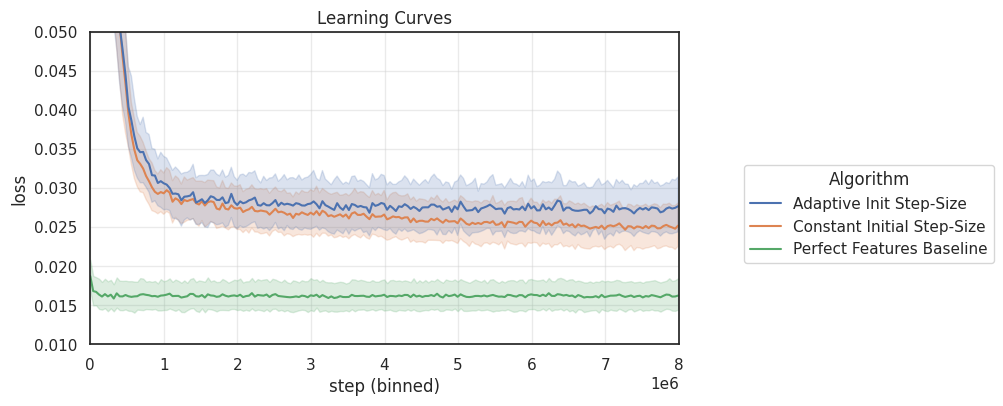

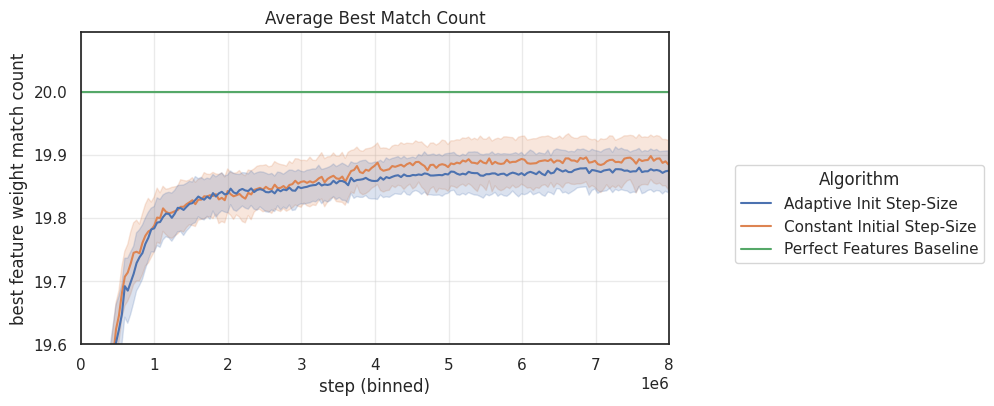

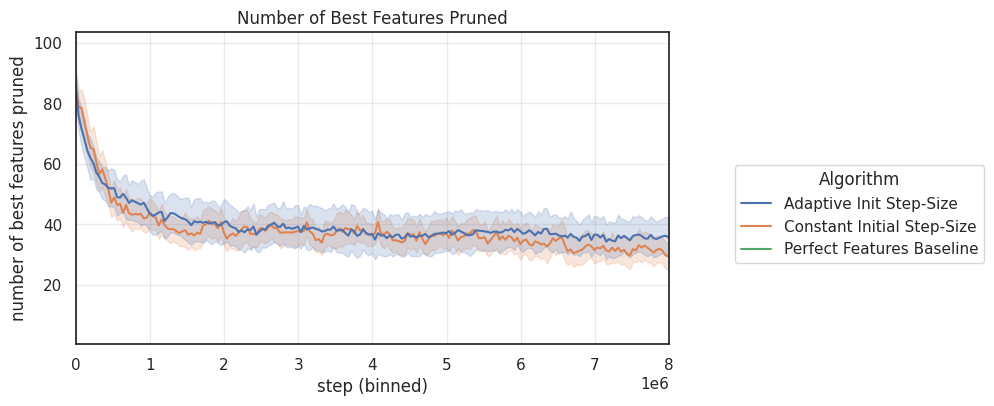

In [23]:
shared_args = {
    'run_df': plot_run_df,
    'config_df': plot_config_df,
    'n_bins': 200,
    'figsize': (7, 4),
    'hue_col': 'algo',
    'legend_title': 'Algorithm',
    'show_ci': True,
}

plot_learning_curves(**shared_args)
plt.title('Learning Curves')
plt.ylim(0.01, 0.05)
plt.show()


plot_learning_curves(
    y_col = 'feature_match/average_best_match_count',
    y_label = 'best feature weight match count',
    **shared_args,
)
plt.title('Average Best Match Count')
plt.ylim(19.6)
plt.show()


plot_learning_curves(
    y_col = 'pruning_stats/n_best_features_pruned',
    y_label = 'number of best features pruned',
    **shared_args,
)
plt.title('Number of Best Features Pruned')
plt.show()